## Model Training On Real Data

In [1]:
# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
transactions_data = pd.read_csv("data/credit_card_data_real.zip", compression="zip")
print(transactions_data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## Class Imbalance

As it can be seen here there is a class imbalance poblem with the dataset. The fraudulent transactions are only 492 or less than 1% of the entire dataset

In [3]:
print(transactions_data["Class"].value_counts())
print()
print(transactions_data["Class"].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


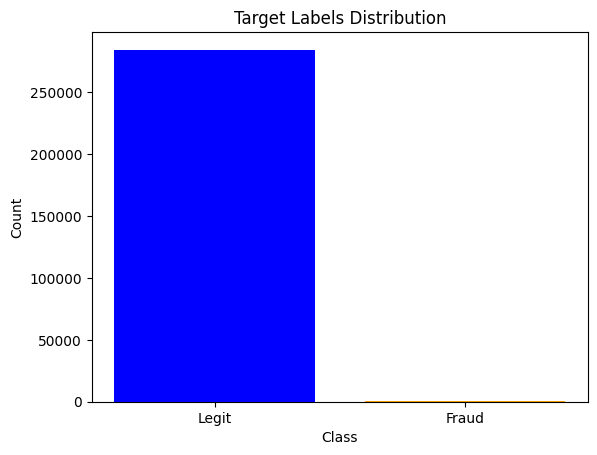

In [4]:
plt.bar(transactions_data["Class"].value_counts().index, transactions_data["Class"].value_counts().values, color=["blue", "orange"])
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Labels Distribution")
plt.show()

## Data Preparation

### Data Resampling

As seen before the data has to be resampled to mitigate the class imbalance problem. SMOTE is used again to over-sample the minority class

In [5]:
from imblearn.over_sampling import SMOTE

X = transactions_data.drop(["Class"], axis=1)
y = transactions_data["Class"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

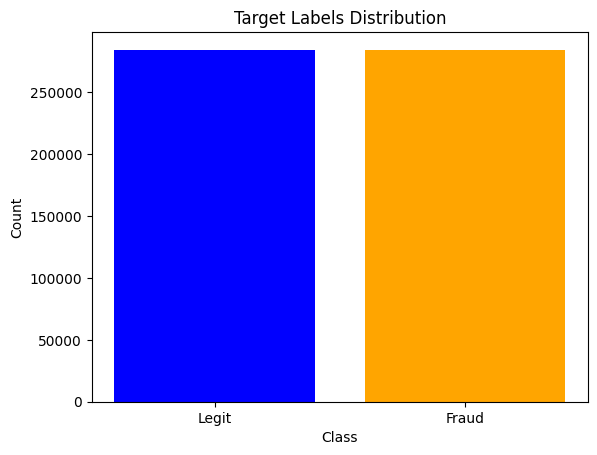

In [6]:
plt.bar(y_resampled.value_counts().index, y_resampled.value_counts().values, color=["blue", "orange"])
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Labels Distribution")
plt.show()

## Model Building

It's time to try a few machine learning models and see how they perform on real data.

In [7]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

### Evaluation Metrics

Given the imbalnced dataset, some suitable metrics are __ROC AUC__ score, __average precision__ score and __f1__ score.

- **ROC AUC**: is the area under the Receiver Operating Characteristic curve

- **average precision**: summarizes a precision-recall curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

$$ AP = \sum(R_n - R_{n - 1})P_n $$

  where $P_n$ and $ R_n $ are the precision and recall at the nth threshold 

- **f1 score**: is the harmonic mean of precision and recall
$$ F1 = \frac{2 * TP}{2 * TP + FP + FN} $$

### Logistic Regression

Bellow a pipeline was created with StandardScaler, SMOTE over-sampling and a LogisticRegression model. The model was trained using stratified cross-validation and achived a roc_aus score of 98%, average precision score of 74% and f1 score of 11%

In [8]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define components 
scaler = StandardScaler()
log_reg = LogisticRegression(random_state=42, class_weight="balanced")

# Define pipeline
log_reg_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", log_reg)
    ]
)

# Cross-validation Iterator
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics
scoring = {
    "roc_aus": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

# Run cv
results = cross_validate(
    log_reg_pipeline,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    return_estimator=True,
    return_indices=True
)

for metric in scoring:
    print(f"{metric}: {results["test_" + metric].mean():.4f}")

roc_aus: 0.9780
pr_auc: 0.7425
f1: 0.1114


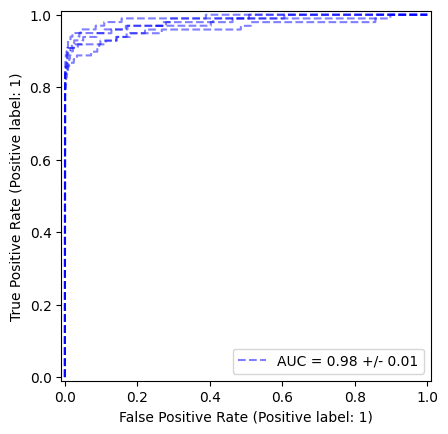

In [9]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_cv_results(results, X, y)
plt.show()

### Stochastic Gradient Descent Classifier

Bellow a pipeline was created with StandardScaler, SMOTE over-sampling and a SGDClassifier model. The model was trained using stratified cross-validation and achived a roc_aus score of 98%, average precision score of 73% and f1 score of 10%

In [10]:
sgd_clf = SGDClassifier(random_state=42, class_weight="balanced")

sgd_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", sgd_clf)
    ]
)

results = cross_validate (
    sgd_pipeline,
    X, y, 
    scoring=scoring,
    cv=cv,
    return_train_score=False,
    return_estimator=True,
    return_indices=True
)

for metric in scoring:
    print(f"{metric}: {results["test_" + metric].mean():.4f}")

roc_aus: 0.9788
pr_auc: 0.7389
f1: 0.1054


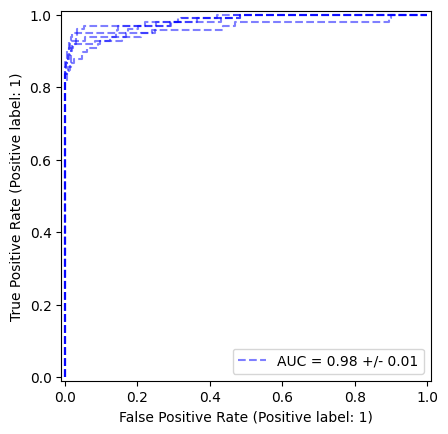

In [11]:
RocCurveDisplay.from_cv_results(results, X, y)
plt.show()

### Gradient Boosting Classifier

The Gradient Boosting Classifier pipieline achived a roc_auc score of 97%, 83% average precision score and 66% f1 score. This is the best model so far although it takes longer to train

In [12]:
gb_clf = HistGradientBoostingClassifier(random_state=42)

gb_clf_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", gb_clf)
    ]
)

results = cross_validate(
    gb_clf_pipeline,
    X, y,
    scoring=scoring,
    cv=cv,
    return_train_score=False,
    return_estimator=True,
    return_indices=True
)

for metric in scoring:
    print(f"{metric}: {results["test_" + metric].mean():.4f}")

roc_aus: 0.9707
pr_auc: 0.8324
f1: 0.6622


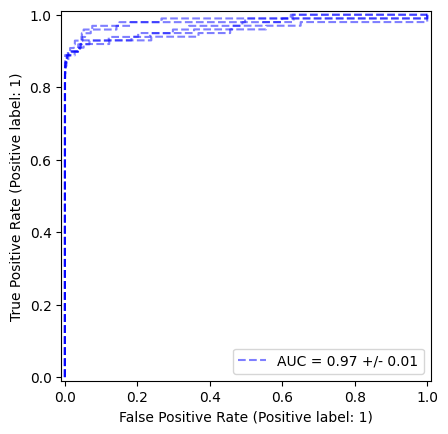

In [13]:
RocCurveDisplay.from_cv_results(results, X, y)
plt.show()

### Hyper-parameter Tuning

### Logistic Regression

In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__fit_intercept": [False, True],
    "model__class_weight": [None, "balanced"]
}

rand_search = RandomizedSearchCV(
    log_reg_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__fit_intercept': [False, True], 'smote__k_neighbors': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

In [15]:
best_model = rand_search.best_estimator_
best_params = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best hyper-parameters: {best_params}")
print(f"Best score: {best_score:.4f}")

Best hyper-parameters: {'smote__sampling_strategy': 0.2, 'smote__k_neighbors': 3, 'model__fit_intercept': True, 'model__class_weight': None, 'model__C': 10}
Best score: 0.7523


### Stochastic Gradient Descent Classifier

In [16]:
param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__alpha": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1],
    "model__loss": ["hinge", "log_loss"],
}

rand_search = RandomizedSearchCV(
    sgd_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__alpha': [1e-05, 0.0001, ...], 'model__loss': ['hinge', 'log_loss'], 'smote__k_neighbors': [3, 5, ...], 'smote__sampling_strategy': [0.2, 0.5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validatio

In [17]:
best_model = rand_search.best_estimator_
best_params = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best hyper-parameters: {best_params}")
print(f"Best score: {best_score:.4f}")

Best hyper-parameters: {'smote__sampling_strategy': 0.5, 'smote__k_neighbors': 7, 'model__loss': 'log_loss', 'model__alpha': 1}
Best score: 0.7457


### Gradient Boosting Classifier

In [19]:
param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__learning_rate": np.arange(0.01, 0.02, 0.01),
    "model__max_depth": [3, 5, 7, 9]
}

rand_search = RandomizedSearchCV(
    gb_clf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': array([0.01]), 'model__max_depth': [3, 5, ...], 'smote__k_neighbors': [3, 5, ...], 'smote__sampling_strategy': [0.2, 0.5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation st

In [20]:
best_model = rand_search.best_estimator_
best_params = rand_search.best_params_
best_score = rand_search.best_score_

print(f"Best hyper-parameters: {best_params}")
print(f"Best score: {best_score:.4f}")

Best hyper-parameters: {'smote__sampling_strategy': 0.2, 'smote__k_neighbors': 7, 'model__max_depth': 5, 'model__learning_rate': np.float64(0.01)}
Best score: 0.7640
